<a href="https://colab.research.google.com/github/KatreenGhobrial/RepoCloudComputing/blob/main/HW/HW2/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip -q install gradio pandas matplotlib pillow requests

In [18]:
# ==========================================
# CELL 1: Imports + Common Styles
# ==========================================

import os
import base64
import json
import html as html_lib
from datetime import datetime

import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import gradio as gr


# -----------------------------
# General helpers
# -----------------------------
def safe_html(value):
    if value is None:
        return ""
    return html_lib.escape(str(value))


# -----------------------------
# Global CSS for the full app
# -----------------------------
GLOBAL_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap');

.gradio-container {
    background-color: #0b110b !important;
    color: #ffffff !important;
    font-family: 'Inter', sans-serif !important;
    padding: 0 !important;
    max-width: 100% !important;
}

.gr-box, .gr-input, .gr-panel {
    background-color: #131c13 !important;
    border: 1px solid #2d402d !important;
    color: white !important;
    border-radius: 10px !important;
}

button.primary {
    background-color: #3a7d2a !important;
    color: #fff !important;
    font-weight: bold !important;
    border: none !important;
    border-radius: 16px !important;
    padding: 10px 24px !important;
}

button.primary:hover {
    background-color: #4e9e38 !important;
}

/* Navbar from Gradio Tabs */
div.tab-nav {
    background-color: #111a11 !important;
    padding: 0px 32px !important;
    display: flex !important;
    justify-content: flex-start !important;
    gap: 24px !important;
    border-bottom: 1px solid rgba(74,124,46,0.3) !important;
    margin-top: 0 !important;
}

div.tab-nav button {
    border: none !important;
    background: transparent !important;
    color: #9cb896 !important;
    font-weight: 600 !important;
    font-size: 14px !important;
    padding: 16px 0 !important;
    border-radius: 0 !important;
    white-space: nowrap !important;
}

div.tab-nav button.selected {
    color: #4ade80 !important;
    border-bottom: 2px solid #4ade80 !important;
    background: transparent !important;
}

div.tab-nav button:hover {
    color: #c2eaaf !important;
}

div.tabitem {
    border: none !important;
    padding: 20px !important;
}

/* Logo */
.app-logo {
    background-color: #111a11;
    padding: 16px 32px 0px 32px;
    display: flex;
    align-items: center;
    gap: 12px;
    font-family: 'Inter', sans-serif;
}

.app-logo-title {
    color: #4ade80;
    font-size: 20px;
    font-weight: 800;
    letter-spacing: 0.5px;
}

/* Shared app background */
.bg-app {
    font-family: 'Inter', sans-serif;
    background: linear-gradient(145deg, #0a0f07 0%, #0d1a08 50%, #0a1205 100%);
    color: #e8f0e4;
    border-radius: 16px;
    padding: 28px;
    margin-bottom: 18px;
    border: 1px solid rgba(74,124,46,0.15);
}

.screen-header {
    display: flex;
    align-items: center;
    gap: 16px;
    margin-bottom: 24px;
    padding-bottom: 18px;
    border-bottom: 1px solid rgba(74,124,46,0.15);
}

.screen-header .icon {
    font-size: 34px;
    width: 56px;
    height: 56px;
    display: flex;
    align-items: center;
    justify-content: center;
    background: rgba(58,125,42,0.15);
    border-radius: 14px;
    border: 1px solid rgba(58,125,42,0.25);
}

.bg-app h1 {
    font-size: 28px;
    font-weight: 800;
    letter-spacing: -0.5px;
    color: #4ade80;
    margin: 0;
}

.subtitle {
    color: #9cb896;
    font-size: 14px;
    margin-top: 4px;
}

/* Cards */
.glass-card {
    background: rgba(26, 38, 20, 0.55);
    border: 1px solid rgba(74, 124, 46, 0.18);
    border-radius: 16px;
    padding: 24px;
    box-shadow: 0 4px 24px rgba(0,0,0,0.3);
}

.metrics-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));
    gap: 16px;
    margin-bottom: 24px;
}

.metric-card {
    background: rgba(26, 38, 20, 0.55);
    border: 1px solid rgba(74,124,46,0.18);
    border-radius: 14px;
    padding: 20px;
    text-align: center;
}

.metric-card .metric-icon {
    font-size: 28px;
    margin-bottom: 10px;
}

.metric-card .metric-value {
    font-size: 28px;
    font-weight: 800;
    color: #e8f0e4;
    margin-bottom: 4px;
}

.metric-card .metric-label {
    font-size: 12px;
    color: #9cb896;
    text-transform: uppercase;
    letter-spacing: 1px;
    font-weight: 500;
}

/* Badges */
.badge {
    display: inline-flex;
    align-items: center;
    gap: 4px;
    padding: 4px 10px;
    border-radius: 20px;
    font-size: 11px;
    font-weight: 700;
}

.badge-success {
    background: rgba(34,197,94,0.15);
    color: #4ade80;
    border: 1px solid rgba(34,197,94,0.25);
}

.badge-warning {
    background: rgba(245,158,11,0.15);
    color: #fbbf24;
    border: 1px solid rgba(245,158,11,0.25);
}

.badge-danger {
    background: rgba(239,68,68,0.15);
    color: #fca5a5;
    border: 1px solid rgba(239,68,68,0.25);
}

.badge-info {
    background: rgba(59,130,246,0.15);
    color: #93c5fd;
    border: 1px solid rgba(59,130,246,0.25);
}

.badge-neutral {
    background: rgba(148,163,184,0.15);
    color: #cbd5e1;
    border: 1px solid rgba(148,163,184,0.2);
}

/* Empty state */
.empty-state {
    text-align: center;
    padding: 48px 24px;
    color: #5a7a52;
}

.empty-state .empty-icon {
    font-size: 56px;
    margin-bottom: 16px;
}

/* Upload screen */
.upload-zone {
    border: 2px dashed rgba(74,124,46,0.35);
    border-radius: 20px;
    padding: 42px 28px;
    text-align: center;
    background: rgba(15,26,10,0.35);
    margin-bottom: 24px;
}

.upload-zone-title {
    font-size: 18px;
    font-weight: 700;
    color: #c2eaaf;
    margin-bottom: 8px;
}

.upload-zone-subtitle {
    font-size: 13px;
    color: #5a7a52;
}

.gallery-header {
    display: flex;
    align-items: center;
    justify-content: space-between;
    gap: 12px;
    flex-wrap: wrap;
}

.section-title {
    font-size: 16px;
    font-weight: 700;
    color: #e8f0e4;
    display: flex;
    align-items: center;
    gap: 8px;
}

.section-title .count {
    background: rgba(58,125,42,0.2);
    color: #6bbf4e;
    font-size: 12px;
    font-weight: 700;
    padding: 2px 10px;
    border-radius: 20px;
}

.gallery-grid {
    display: grid;
    grid-template-columns: repeat(auto-fill, minmax(260px, 1fr));
    gap: 20px;
    margin-top: 20px;
}

.image-card {
    background: rgba(26, 38, 20, 0.55);
    border: 1px solid rgba(74,124,46,0.15);
    border-radius: 16px;
    overflow: hidden;
}

.card-thumb {
    width: 100%;
    height: 200px;
    object-fit: cover;
    display: block;
    border-bottom: 1px solid rgba(74,124,46,0.1);
}

.card-body {
    padding: 16px;
}

.card-filename {
    font-size: 14px;
    font-weight: 600;
    color: #e8f0e4;
    margin-bottom: 6px;
    white-space: nowrap;
    overflow: hidden;
    text-overflow: ellipsis;
}

.card-meta {
    display: flex;
    gap: 12px;
    font-size: 11px;
    color: #5a7a52;
    margin-bottom: 14px;
}

.ai-section {
    border-top: 1px solid rgba(74,124,46,0.3);
    margin-top: 10px;
    padding-top: 10px;
}

.ai-title {
    font-size: 11px;
    color: #5a7a52;
    font-weight: bold;
    text-transform: uppercase;
    letter-spacing: 0.6px;
}

.ai-diagnosis {
    font-size: 14px;
    color: #c2eaaf;
    margin-top: 4px;
    margin-bottom: 8px;
    font-weight: 600;
}

.ai-recs {
    padding-left: 18px;
    font-size: 12px;
    color: #9cb896;
    margin-top: 4px;
    line-height: 1.5;
}

/* Sensor gauges */
.sensor-gauge-wrapper {
    position: relative;
    width: 120px;
    height: 120px;
    margin: 0 auto 16px;
}

.sensor-gauge {
    transform: rotate(-90deg);
    width: 100%;
    height: 100%;
}

.sensor-gauge-bg {
    fill: none;
    stroke: rgba(74,124,46,0.15);
    stroke-width: 10;
}

.sensor-gauge-fill {
    fill: none;
    stroke-width: 10;
    stroke-linecap: round;
}

.sensor-gauge-value {
    position: absolute;
    top: 50%;
    left: 50%;
    transform: translate(-50%, -50%);
    text-align: center;
    width: 100%;
}

.sensor-gauge-text {
    font-size: 24px;
    font-weight: 800;
    color: #ffffff;
    line-height: 1;
}

.sensor-gauge-unit {
    font-size: 12px;
    color: #9cb896;
    margin-top: 2px;
}

.gauge-temp { stroke: #f97316; }
.gauge-humid { stroke: #3b82f6; }
.gauge-soil { stroke: #22c55e; }
.gauge-light { stroke: #eab308; }

.metrics-row {
    display: flex;
    flex-direction: row;
    justify-content: space-between;
    align-items: stretch;
    flex-wrap: wrap;
    gap: 16px;
    margin-bottom: 24px;
    width: 100%;
}

.metrics-row .metric-card {
    flex: 1;
    min-width: 170px;
}

.sensor-error {
    background: rgba(239,68,68,0.12);
    border: 1px solid rgba(239,68,68,0.3);
    color: #fca5a5;
    padding: 14px;
    border-radius: 12px;
    margin-bottom: 16px;
    font-size: 13px;
}

/* Academic search */
.ai-summary-card {
    background: linear-gradient(135deg, rgba(26,38,20,0.8) 0%, rgba(15,26,10,0.9) 100%);
    border: 1px solid rgba(245,158,11,0.3);
    border-radius: 16px;
    padding: 24px;
    margin-bottom: 24px;
    box-shadow: 0 8px 32px rgba(245,158,11,0.08);
}

.summary-badge {
    background: rgba(245,158,11,0.15);
    color: #fbbf24;
    padding: 4px 10px;
    border-radius: 12px;
    font-size: 11px;
    font-weight: 600;
    margin-top: 16px;
    display: inline-block;
}

.paper-card {
    background: rgba(26,38,20,0.4);
    border: 1px solid rgba(74,124,46,0.15);
    border-radius: 12px;
    padding: 20px;
    margin-bottom: 16px;
}

.indexed-badge {
    background: rgba(58,125,42,0.15);
    color: #6bbf4e;
    padding: 2px 8px;
    border-radius: 10px;
    font-size: 11px;
}

/* Dashboard */
.dashboard-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
    margin-bottom: 20px;
}

@media (max-width: 800px) {
    .dashboard-grid {
        grid-template-columns: 1fr;
    }
}

.health-score {
    font-size: 58px;
    font-weight: 800;
    color: #4ade80;
    line-height: 1;
}

.health-label {
    font-size: 16px;
    color: #c2eaaf;
    margin-top: 8px;
}

.alert-item {
    padding: 12px 14px;
    border-radius: 10px;
    border-left: 3px solid transparent;
    margin-bottom: 8px;
    background: rgba(15,26,10,0.35);
}

.alert-warning { border-left-color: #f59e0b; }
.alert-success { border-left-color: #22c55e; }
.alert-danger { border-left-color: #ef4444; }
.alert-info { border-left-color: #3b82f6; }

.alert-title {
    font-size: 12px;
    font-weight: 800;
    text-transform: uppercase;
    margin-bottom: 3px;
}

.alert-msg {
    font-size: 13px;
    color: #c2eaaf;
}
"""

print("✅ CELL 1 loaded: imports and GLOBAL_CSS are ready.")

✅ CELL 1 loaded: imports and GLOBAL_CSS are ready.


In [19]:
# ==========================================
# CELL 2 FIX: Plant Scanner Logic
# Run this BEFORE Cell 6
# ==========================================

uploaded_images_state = []


def _file_to_path(file_obj):
    if file_obj is None:
        return None

    if isinstance(file_obj, str):
        return file_obj

    if isinstance(file_obj, dict):
        return file_obj.get("path") or file_obj.get("name")

    if hasattr(file_obj, "name"):
        return file_obj.name

    return str(file_obj)


def image_to_base64_data_url(image_path):
    import os
    import base64

    ext = os.path.splitext(image_path)[1].lower()

    mime = "image/jpeg"
    if ext == ".png":
        mime = "image/png"
    elif ext == ".webp":
        mime = "image/webp"

    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")

    return f"data:{mime};base64,{encoded}"


def simple_plant_analysis(image_path):
    from PIL import Image

    try:
        image = Image.open(image_path).convert("RGB")
        pixels = list(image.resize((100, 100)).getdata())

        green_score = 0
        yellow_score = 0
        brown_score = 0

        for r, g, b in pixels:
            if g > r and g > b:
                green_score += 1

            if r > 120 and g > 100 and b < 90:
                yellow_score += 1

            if r > 80 and g < 90 and b < 70:
                brown_score += 1

        total = len(pixels)
        green_ratio = green_score / total
        yellow_ratio = yellow_score / total
        brown_ratio = brown_score / total

        if green_ratio > 0.45 and brown_ratio < 0.10:
            return {
                "status": "healthy",
                "diagnosis": "Healthy basil leaf",
                "recommendations": [
                    "Continue regular watering.",
                    "Keep the plant in strong indirect sunlight.",
                    "Monitor soil moisture every few days."
                ]
            }

        if brown_ratio > 0.18 or yellow_ratio > 0.25:
            return {
                "status": "severe",
                "diagnosis": "Possible severe stress or disease symptoms",
                "recommendations": [
                    "Remove damaged leaves.",
                    "Check for overwatering or poor drainage.",
                    "Separate the plant from healthy plants if symptoms spread."
                ]
            }

        return {
            "status": "mild",
            "diagnosis": "Mild stress signs detected",
            "recommendations": [
                "Check soil moisture level.",
                "Avoid watering the leaves directly.",
                "Continue monitoring the plant for changes."
            ]
        }

    except Exception as e:
        return {
            "status": "unknown",
            "diagnosis": "Could not analyze image",
            "recommendations": [str(e)]
        }


def upload_status_badge(status):
    if status == "healthy":
        return '<span class="badge badge-success">🟢 Healthy</span>'

    if status == "mild":
        return '<span class="badge badge-warning">🟡 Mild Issue</span>'

    if status == "severe":
        return '<span class="badge badge-danger">🔴 Severe Issue</span>'

    return '<span class="badge badge-neutral">Unknown</span>'


def build_upload_stats_html():
    total = len(uploaded_images_state)
    healthy = sum(1 for img in uploaded_images_state if img["status"] == "healthy")
    issues = sum(1 for img in uploaded_images_state if img["status"] in ["mild", "severe"])
    storage_kb = sum(img["size_kb"] for img in uploaded_images_state)

    return f"""
    <div class="metrics-grid">
        <div class="metric-card">
            <div class="metric-icon">🖼️</div>
            <div class="metric-value">{total}</div>
            <div class="metric-label">Images Uploaded</div>
        </div>

        <div class="metric-card">
            <div class="metric-icon">💾</div>
            <div class="metric-value">{round(storage_kb, 1)} KB</div>
            <div class="metric-label">Storage Used</div>
        </div>

        <div class="metric-card">
            <div class="metric-icon">✅</div>
            <div class="metric-value">{healthy}</div>
            <div class="metric-label">Healthy</div>
        </div>

        <div class="metric-card">
            <div class="metric-icon">⚠️</div>
            <div class="metric-value">{issues}</div>
            <div class="metric-label">Issues Detected</div>
        </div>
    </div>
    """


def build_gallery_html(filter_value="all"):
    if not uploaded_images_state:
        return """
        <div class="empty-state">
            <div class="empty-icon">🍃</div>
            <h3>Upload your first basil plant image</h3>
            <p>Upload an image to analyze plant health and see recommendations.</p>
        </div>
        """

    images = uploaded_images_state

    if filter_value == "healthy":
        images = [img for img in images if img["status"] == "healthy"]

    elif filter_value == "issues":
        images = [img for img in images if img["status"] in ["mild", "severe"]]

    if not images:
        return """
        <div class="empty-state">
            <div class="empty-icon">🔍</div>
            <h3>No images match this filter</h3>
        </div>
        """

    cards = ""

    for img in images:
        recs = "".join(f"<li>{safe_html(r)}</li>" for r in img["recommendations"])

        cards += f"""
        <div class="image-card">
            <div class="card-thumb-wrap">
                <img class="card-thumb" src="{img["preview"]}" />
            </div>

            <div class="card-body">
                <div class="card-filename">{safe_html(img["name"])}</div>

                <div class="card-meta">
                    <span>📏 {img["size_kb"]:.1f} KB</span>
                    <span>🕒 {safe_html(img["timestamp"])}</span>
                </div>

                <div style="margin-bottom:8px;">
                    {upload_status_badge(img["status"])}
                </div>

                <div class="ai-section">
                    <div class="ai-title">Plant Diagnosis</div>
                    <div class="ai-diagnosis">{safe_html(img["diagnosis"])}</div>

                    <div class="ai-title" style="margin-top:12px;">Recommended Steps</div>
                    <ul class="ai-recs">{recs}</ul>
                </div>
            </div>
        </div>
        """

    return f"""
    <div class="glass-card">
        <div class="gallery-header">
            <div class="section-title">
                🌱 Plant Gallery <span class="count">{len(images)}</span>
            </div>
        </div>

        <div class="gallery-grid">
            {cards}
        </div>
    </div>
    """


def upload_and_analyze_images(files, filter_value):
    import os
    from datetime import datetime

    if files is None:
        return build_upload_stats_html(), build_gallery_html(filter_value), "No files uploaded."

    if not isinstance(files, list):
        files = [files]

    analyzed = 0

    for file_obj in files:
        file_path = _file_to_path(file_obj)

        if not file_path or not os.path.exists(file_path):
            continue

        analysis = simple_plant_analysis(file_path)
        size_kb = os.path.getsize(file_path) / 1024
        name = os.path.basename(file_path)

        uploaded_images_state.insert(0, {
            "name": name,
            "path": file_path,
            "preview": image_to_base64_data_url(file_path),
            "size_kb": size_kb,
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
            "status": analysis["status"],
            "diagnosis": analysis["diagnosis"],
            "recommendations": analysis["recommendations"]
        })

        analyzed += 1

    return (
        build_upload_stats_html(),
        build_gallery_html(filter_value),
        f"Analyzed {analyzed} image(s)."
    )


def update_gallery_filter(filter_value):
    return build_upload_stats_html(), build_gallery_html(filter_value)


def clear_uploaded_images():
    uploaded_images_state.clear()
    return build_upload_stats_html(), build_gallery_html("all"), "Gallery cleared."


print("✅ Plant Scanner functions loaded successfully.")

✅ Plant Scanner functions loaded successfully.


In [20]:
# ==========================================
# CELL 3: IoT Sensor Logic
# ==========================================

BASE_URL = "https://server-cloud-v645.onrender.com"
VALID_FEEDS = ["humidity", "soil", "temperature", "json"]


def fetch_feed(feed="humidity", limit=10):
    feed = str(feed).strip().lower()

    try:
        limit = int(limit)
    except Exception:
        limit = 10

    limit = max(1, min(limit, 100))

    if feed not in VALID_FEEDS:
        return {"error": f"Invalid feed: {feed}"}, pd.DataFrame()

    try:
        response = requests.get(
            f"{BASE_URL}/history",
            params={"feed": feed, "limit": limit},
            timeout=20
        )
        response.raise_for_status()
        payload = response.json()

    except requests.exceptions.RequestException as e:
        return {"error": f"Server request failed: {e}"}, pd.DataFrame()

    except ValueError:
        return {"error": "Server returned a response that is not valid JSON."}, pd.DataFrame()

    if "data" not in payload:
        return {"error": f"Unexpected server response: {payload}"}, pd.DataFrame()

    df = pd.DataFrame(payload["data"])

    if df.empty:
        return payload, df

    if "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
        df = df.sort_values("created_at")

    if "value" in df.columns:
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

    return payload, df


def get_latest_value(feed):
    payload, df = fetch_feed(feed, limit=1)

    if "error" in payload:
        return None, payload["error"]

    if df.empty or "value" not in df.columns:
        return None, f"No data found for {feed}"

    clean_values = df["value"].dropna()

    if clean_values.empty:
        return None, f"No numeric value found for {feed}"

    return float(clean_values.iloc[-1]), None


def get_all_latest_sensor_values():
    values = {}
    errors = []

    for feed in ["temperature", "humidity", "soil"]:
        value, error = get_latest_value(feed)
        values[feed] = value

        if error:
            errors.append(error)

    return values, errors


def sensor_status(feed, value):
    if value is None:
        return "No Data", "badge-danger"

    if feed == "temperature":
        if 18 <= value <= 30:
            return "Optimal", "badge-success"
        return "Warning", "badge-warning"

    if feed == "humidity":
        if 40 <= value <= 75:
            return "Optimal", "badge-success"
        return "Warning", "badge-warning"

    if feed == "soil":
        if value >= 40:
            return "Optimal", "badge-success"
        return "Low", "badge-warning"

    return "OK", "badge-success"


def gauge_percent(feed, value):
    if value is None:
        return 0

    if feed == "temperature":
        return max(0, min(100, ((value - 15) / 20) * 100))

    if feed == "humidity":
        return max(0, min(100, ((value - 20) / 70) * 100))

    if feed == "soil":
        return max(0, min(100, ((value - 10) / 80) * 100))

    if feed == "light":
        return max(0, min(100, (value / 1500) * 100))

    return 0


def gauge_dashoffset(percent):
    circumference = 251.2
    return circumference - (percent / 100.0) * circumference


def build_sensor_cards_html():
    values, errors = get_all_latest_sensor_values()

    temp = values.get("temperature")
    humidity = values.get("humidity")
    soil = values.get("soil")

    # כרגע אין feed אמיתי של light בקוד המקורי, אז נשאיר דמו.
    light = 600

    temp_status, temp_class = sensor_status("temperature", temp)
    humidity_status, humidity_class = sensor_status("humidity", humidity)
    soil_status, soil_class = sensor_status("soil", soil)
    light_status, light_class = "Optimal", "badge-success"

    def fmt(value, digits=0):
        if value is None:
            return "--"
        return round(value, digits)

    error_html = ""
    if errors:
        error_html = f"""
        <div class="sensor-error">
            ⚠ Some sensor requests failed:<br>
            {"<br>".join(safe_html(e) for e in errors)}
        </div>
        """

    temp_pct = gauge_percent("temperature", temp)
    humid_pct = gauge_percent("humidity", humidity)
    soil_pct = gauge_percent("soil", soil)
    light_pct = gauge_percent("light", light)

    return f"""
    <div class="bg-app">
        <div class="screen-header">
            <div class="icon">📡</div>
            <div>
                <h1>IoT Sensor Data</h1>
                <p class="subtitle">Real-time telemetry from Render Server</p>
            </div>
        </div>

        {error_html}

        <div class="metrics-row">

            <div class="metric-card">
                <div class="sensor-gauge-wrapper">
                    <svg class="sensor-gauge" viewBox="0 0 100 100">
                        <circle class="sensor-gauge-bg" cx="50" cy="50" r="40"></circle>
                        <circle class="sensor-gauge-fill gauge-temp"
                                cx="50" cy="50" r="40"
                                stroke-dasharray="251.2"
                                stroke-dashoffset="{gauge_dashoffset(temp_pct)}"></circle>
                    </svg>
                    <div class="sensor-gauge-value">
                        <div class="sensor-gauge-text">{fmt(temp, 1)}</div>
                        <div class="sensor-gauge-unit">°C</div>
                    </div>
                </div>
                <div class="metric-label">Temperature</div>
                <div><span class="badge {temp_class}">{temp_status}</span></div>
            </div>

            <div class="metric-card">
                <div class="sensor-gauge-wrapper">
                    <svg class="sensor-gauge" viewBox="0 0 100 100">
                        <circle class="sensor-gauge-bg" cx="50" cy="50" r="40"></circle>
                        <circle class="sensor-gauge-fill gauge-humid"
                                cx="50" cy="50" r="40"
                                stroke-dasharray="251.2"
                                stroke-dashoffset="{gauge_dashoffset(humid_pct)}"></circle>
                    </svg>
                    <div class="sensor-gauge-value">
                        <div class="sensor-gauge-text">{fmt(humidity, 0)}</div>
                        <div class="sensor-gauge-unit">%</div>
                    </div>
                </div>
                <div class="metric-label">Air Humidity</div>
                <div><span class="badge {humidity_class}">{humidity_status}</span></div>
            </div>

            <div class="metric-card">
                <div class="sensor-gauge-wrapper">
                    <svg class="sensor-gauge" viewBox="0 0 100 100">
                        <circle class="sensor-gauge-bg" cx="50" cy="50" r="40"></circle>
                        <circle class="sensor-gauge-fill gauge-soil"
                                cx="50" cy="50" r="40"
                                stroke-dasharray="251.2"
                                stroke-dashoffset="{gauge_dashoffset(soil_pct)}"></circle>
                    </svg>
                    <div class="sensor-gauge-value">
                        <div class="sensor-gauge-text">{fmt(soil, 0)}</div>
                        <div class="sensor-gauge-unit">%</div>
                    </div>
                </div>
                <div class="metric-label">Soil Moisture</div>
                <div><span class="badge {soil_class}">{soil_status}</span></div>
            </div>

            <div class="metric-card">
                <div class="sensor-gauge-wrapper">
                    <svg class="sensor-gauge" viewBox="0 0 100 100">
                        <circle class="sensor-gauge-bg" cx="50" cy="50" r="40"></circle>
                        <circle class="sensor-gauge-fill gauge-light"
                                cx="50" cy="50" r="40"
                                stroke-dasharray="251.2"
                                stroke-dashoffset="{gauge_dashoffset(light_pct)}"></circle>
                    </svg>
                    <div class="sensor-gauge-value">
                        <div class="sensor-gauge-text">{fmt(light, 0)}</div>
                        <div class="sensor-gauge-unit">lux</div>
                    </div>
                </div>
                <div class="metric-label">Light Intensity</div>
                <div><span class="badge {light_class}">{light_status}</span></div>
            </div>

        </div>
    </div>
    """


def make_sensor_plot(feed, limit):
    payload, df = fetch_feed(feed, limit)

    fig, ax = plt.subplots(figsize=(10, 4))

    if "error" in payload:
        ax.text(0.5, 0.5, payload["error"], ha="center", va="center")
        ax.set_axis_off()
        return fig

    if df.empty or "value" not in df.columns:
        ax.text(0.5, 0.5, "No data available", ha="center", va="center")
        ax.set_axis_off()
        return fig

    if "created_at" in df.columns:
        x = df["created_at"]
        ax.set_xlabel("Time")
    else:
        x = df.index
        ax.set_xlabel("Sample")

    ax.plot(x, df["value"], marker="o")
    ax.set_title(f"{feed.capitalize()} History")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()

    return fig


def get_sensor_table(feed, limit):
    payload, df = fetch_feed(feed, limit)

    if "error" in payload:
        return pd.DataFrame({"Error": [payload["error"]]})

    if df.empty:
        return pd.DataFrame({"Message": ["No data available"]})

    columns_to_show = []

    if "created_at" in df.columns:
        columns_to_show.append("created_at")

    if "value" in df.columns:
        columns_to_show.append("value")

    if not columns_to_show:
        return df

    table_df = df[columns_to_show].copy()

    if "created_at" in table_df.columns:
        table_df = table_df.sort_values("created_at", ascending=False)

    return table_df


def refresh_sensor_dashboard(feed, limit):
    cards_html = build_sensor_cards_html()
    table_df = get_sensor_table(feed, limit)
    plot_fig = make_sensor_plot(feed, limit)

    now = datetime.now().strftime("%H:%M:%S")
    status = f"Last updated: {now} | Feed: {feed} | Samples: {limit}"

    return cards_html, table_df, plot_fig, status


def clear_sensor_dashboard(feed, limit):
    empty_df = pd.DataFrame(columns=["created_at", "value"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.text(0.5, 0.5, "Chart cleared", ha="center", va="center")
    ax.set_axis_off()

    return build_sensor_cards_html(), empty_df, fig, "Chart cleared."


def toggle_live(is_live):
    new_state = not bool(is_live)

    if new_state:
        return (
            new_state,
            gr.update(active=True),
            gr.update(value="⏸ Stop Live Refresh"),
            "🟢 Connected - live refresh is ON"
        )

    return (
        new_state,
        gr.update(active=False),
        gr.update(value="▶ Start Live Refresh"),
        "🔴 Disconnected - live refresh is OFF"
    )


print("✅ CELL 3 loaded: IoT sensor logic is ready.")

✅ CELL 3 loaded: IoT sensor logic is ready.


In [21]:
# ==========================================
# CELL 4: Academic Search / RAG Logic
# ==========================================

OPENAI_API_KEY = "sk-..."  # הכניסי מפתח אמיתי רק במחברת, לא בגיט


def initialize_rag_if_needed():
    """
    Uses existing rag_system if it exists.
    Otherwise tries to initialize it from EcologicalRAG and basil_papers.
    """
    global rag_system

    if "rag_system" in globals():
        return True, "RAG system already loaded."

    if "EcologicalRAG" not in globals():
        return False, "EcologicalRAG class is not defined. Run your RAG/index cells first."

    if "basil_papers" not in globals():
        return False, "basil_papers is not defined. Run the cell that loads your academic papers first."

    try:
        rag_system = EcologicalRAG(openai_api_key=OPENAI_API_KEY)
        rag_system.load_papers(basil_papers)
        return True, "RAG system initialized successfully."

    except Exception as e:
        return False, f"Failed to initialize RAG system: {e}"


def advanced_html_search(query):
    if not query or not query.strip():
        return """
        <div style='color:#ef4444; padding:20px; font-family: Inter, sans-serif;'>
            Please enter a search term.
        </div>
        """

    ok, message = initialize_rag_if_needed()

    if not ok:
        return f"""
        <div style='color:#ef4444; padding:20px; font-family: Inter, sans-serif;'>
            {safe_html(message)}
        </div>
        """

    try:
        rag_result = rag_system.query(query, n_results=3)
        ai_summary = rag_result.get("response", "")

        search_data = rag_system.search(query, n_results=3)
        doc_ids = search_data.get("ids", [[]])[0]

        ai_summary_html = safe_html(ai_summary).replace("\n", "<br>")

        html_output = f"""
        <div style="font-family: 'Inter', sans-serif;">
            <div class="ai-summary-card">
                <div style="display:flex; align-items:center; gap:12px; margin-bottom:16px; color:#fbbf24;">
                    <span style="font-size:20px;">✨</span>
                    <h3 style="margin:0; color:#fbbf24; font-size:18px;">AI-Enhanced Summary</h3>
                </div>

                <div style="color:#e8f0e4; font-size:15px; line-height:1.7;">
                    {ai_summary_html}
                </div>

                <div class="summary-badge">
                    Generated from {len(doc_ids)} top research papers
                </div>
            </div>

            <div style='color:#9cb896; font-size:14px; margin-bottom:20px;'>
                Found {len(doc_ids)} relevant academic result(s):
            </div>
        """

        for doc_id in doc_ids:
            try:
                idx = int(str(doc_id).split("_")[1])
                paper = rag_system.papers[idx]
            except Exception:
                continue

            title = safe_html(paper.get("title", "Unknown"))
            authors = safe_html(paper.get("authors", "Unknown"))
            abstract = safe_html(paper.get("abstract", ""))

            html_output += f"""
            <div class="paper-card">
                <div style="font-size:18px; font-weight:600; color:#c2eaaf; margin-bottom:8px;">
                    {title}
                </div>
                <div style="font-size:13px; color:#9cb896; margin-bottom:12px;">
                    {authors}
                </div>
                <div style="font-size:14px; color:#d1d5db; line-height:1.6;">
                    {abstract}
                </div>
                <div style="margin-top:16px; padding-top:12px; border-top:1px solid rgba(74,124,46,0.1);">
                    <span class="indexed-badge">Indexed Academic Paper</span>
                </div>
            </div>
            """

        html_output += "</div>"
        return html_output

    except Exception as e:
        return f"""
        <div style='color:#ef4444; padding:20px; font-family: Inter, sans-serif;'>
            Search error: {safe_html(e)}
        </div>
        """


print("✅ CELL 4 loaded: Academic search logic is ready.")

✅ CELL 4 loaded: Academic search logic is ready.


In [22]:
# ==========================================
# CELL 5: Visual Dashboard Logic
# ==========================================

def range_score(value, min_good, max_good, hard_min, hard_max):
    """
    Returns a score from 0 to 100.
    100 if value is inside the good range.
    Lower if outside the range.
    """
    if value is None:
        return 50

    if min_good <= value <= max_good:
        return 100

    if value < min_good:
        if value <= hard_min:
            return 0
        return int(((value - hard_min) / (min_good - hard_min)) * 100)

    if value > max_good:
        if value >= hard_max:
            return 0
        return int(((hard_max - value) / (hard_max - max_good)) * 100)

    return 50


def compute_health_score(values):
    temp = values.get("temperature")
    humidity = values.get("humidity")
    soil = values.get("soil")

    temp_score = range_score(temp, 18, 30, 5, 40)
    humidity_score = range_score(humidity, 40, 75, 10, 95)
    soil_score = range_score(soil, 40, 80, 0, 100)

    # soil is most important for plant condition here
    total_score = int((temp_score * 0.30) + (humidity_score * 0.25) + (soil_score * 0.45))

    return max(0, min(100, total_score))


def dashboard_health_label(score):
    if score >= 80:
        return "Excellent", "badge-success"
    if score >= 65:
        return "Good", "badge-success"
    if score >= 45:
        return "Needs Attention", "badge-warning"
    return "Critical", "badge-danger"


def build_dashboard_alerts(values, errors):
    alerts = ""

    if errors:
        alerts += """
        <div class="alert-item alert-danger">
            <div class="alert-title" style="color:#fca5a5;">Connection</div>
            <div class="alert-msg">Some sensor requests failed. Check the Render server connection.</div>
        </div>
        """

    temp = values.get("temperature")
    humidity = values.get("humidity")
    soil = values.get("soil")

    if soil is not None and soil < 40:
        alerts += """
        <div class="alert-item alert-warning">
            <div class="alert-title" style="color:#fbbf24;">Soil Warning</div>
            <div class="alert-msg">Soil moisture is low. Consider watering the basil plant.</div>
        </div>
        """

    if temp is not None and temp > 30:
        alerts += """
        <div class="alert-item alert-warning">
            <div class="alert-title" style="color:#fbbf24;">Temperature Warning</div>
            <div class="alert-msg">Temperature is above the optimal range.</div>
        </div>
        """

    if humidity is not None and humidity < 40:
        alerts += """
        <div class="alert-item alert-info">
            <div class="alert-title" style="color:#93c5fd;">Humidity Info</div>
            <div class="alert-msg">Air humidity is lower than the recommended range.</div>
        </div>
        """

    if not alerts:
        alerts = """
        <div class="alert-item alert-success">
            <div class="alert-title" style="color:#4ade80;">All Good</div>
            <div class="alert-msg">No unusual sensor alerts detected.</div>
        </div>
        """

    return alerts


def build_visual_dashboard_html():
    values, errors = get_all_latest_sensor_values()

    temp = values.get("temperature")
    humidity = values.get("humidity")
    soil = values.get("soil")
    light = 600

    score = compute_health_score(values)
    label, label_class = dashboard_health_label(score)

    temp_status, temp_class = sensor_status("temperature", temp)
    humidity_status, humidity_class = sensor_status("humidity", humidity)
    soil_status, soil_class = sensor_status("soil", soil)

    def fmt(value, digits=0):
        if value is None:
            return "--"
        return round(value, digits)

    alerts_html = build_dashboard_alerts(values, errors)
    now = datetime.now().strftime("%H:%M:%S")

    return f"""
    <div class="bg-app">
        <div class="screen-header">
            <div class="icon">🌱</div>
            <div style="flex:1;">
                <h1>My Basil Garden</h1>
                <p class="subtitle">Visual Plant Health Dashboard</p>
            </div>
            <div>
                <span class="badge badge-info">Last updated: {now}</span>
            </div>
        </div>

        <div class="dashboard-grid">
            <div class="glass-card" style="text-align:center;">
                <div class="health-score">{score}</div>
                <div class="health-label">Health Score / 100</div>
                <div style="margin-top:14px;">
                    <span class="badge {label_class}">{label}</span>
                </div>
            </div>

            <div class="glass-card">
                <div style="font-size:16px; font-weight:700; color:#e8f0e4; margin-bottom:14px;">
                    🔔 Recent Alerts
                </div>
                {alerts_html}
            </div>
        </div>

        <div class="metrics-grid">
            <div class="metric-card">
                <div class="metric-icon">🌡️</div>
                <div class="metric-value">{fmt(temp, 1)}°C</div>
                <div class="metric-label">Temperature</div>
                <div style="margin-top:10px;"><span class="badge {temp_class}">{temp_status}</span></div>
            </div>

            <div class="metric-card">
                <div class="metric-icon">💧</div>
                <div class="metric-value">{fmt(humidity, 0)}%</div>
                <div class="metric-label">Humidity</div>
                <div style="margin-top:10px;"><span class="badge {humidity_class}">{humidity_status}</span></div>
            </div>

            <div class="metric-card">
                <div class="metric-icon">🪴</div>
                <div class="metric-value">{fmt(soil, 0)}%</div>
                <div class="metric-label">Soil Moisture</div>
                <div style="margin-top:10px;"><span class="badge {soil_class}">{soil_status}</span></div>
            </div>

            <div class="metric-card">
                <div class="metric-icon">☀️</div>
                <div class="metric-value">{light} lux</div>
                <div class="metric-label">Light Intensity</div>
                <div style="margin-top:10px;"><span class="badge badge-success">Optimal</span></div>
            </div>
        </div>

        <div class="dashboard-grid">
            <div class="glass-card">
                <div style="font-size:16px; font-weight:700; color:#e8f0e4; margin-bottom:10px;">
                    🌿 Basil Care Tip
                </div>
                <div style="color:#c2eaaf; line-height:1.7;">
                    Water basil when the top layer of soil feels dry. Avoid overwatering, and keep the plant in a bright location.
                </div>
            </div>

            <div class="glass-card">
                <div style="font-size:16px; font-weight:700; color:#e8f0e4; margin-bottom:10px;">
                    ✅ System Summary
                </div>
                <div style="color:#c2eaaf; line-height:1.7;">
                    The dashboard combines live IoT data with a simple health score to help users understand the plant condition quickly.
                </div>
            </div>
        </div>
    </div>
    """


def refresh_visual_dashboard():
    return build_visual_dashboard_html()


print("✅ CELL 5 loaded: Visual dashboard logic is ready.")

✅ CELL 5 loaded: Visual dashboard logic is ready.


/tmp/ipykernel_16655/221296483.py:13: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=GLOBAL_CSS, theme=gr.themes.Base(), title="My Basil Garden") as interface:
/tmp/ipykernel_16655/221296483.py:13: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=GLOBAL_CSS, theme=gr.themes.Base(), title="My Basil Garden") as interface:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://74fc65c1882923825a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://74fc65c1882923825a.gradio.live


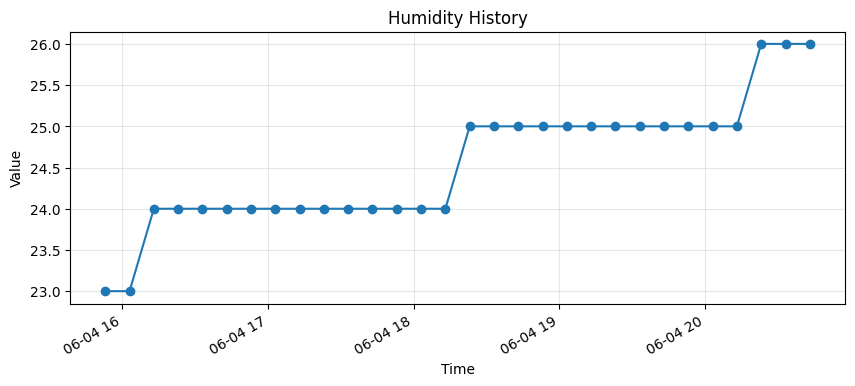

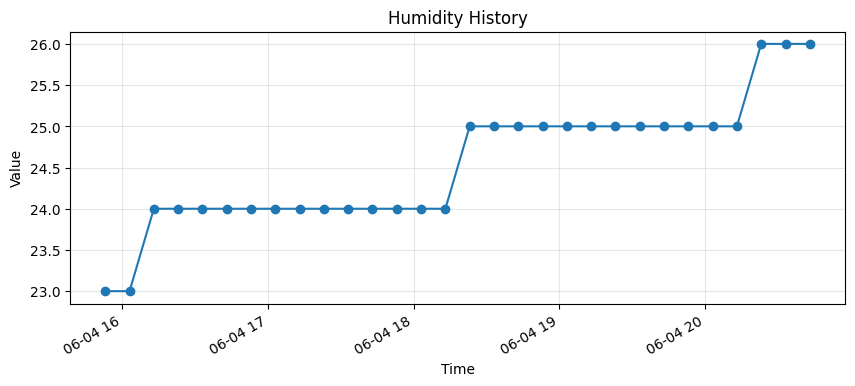

In [23]:
# ==========================================
# CELL 6: Full Gradio App with Navbar - Stable Version
# ==========================================

logo_html = """
<div class="app-logo">
    <span style="font-size:24px;">🌱</span>
    <span class="app-logo-title">My Basil Garden</span>
</div>
"""


with gr.Blocks(css=GLOBAL_CSS, theme=gr.themes.Base(), title="My Basil Garden") as interface:
    gr.HTML(logo_html)

    with gr.Tabs():

        # =====================================================
        # TAB 1: Plant Scanner
        # =====================================================
        with gr.Tab("Plant Scanner"):
            gr.HTML("""
            <div class="bg-app">
                <div class="screen-header">
                    <div class="icon">📸</div>
                    <div>
                        <h1>העלאת תמונות צמחים</h1>
                        <p class="subtitle">Plant image upload and basic health analysis</p>
                    </div>
                </div>

                <div class="upload-zone">
                    <div style="font-size:64px; margin-bottom:16px;">🌿</div>
                    <div class="upload-zone-title">Upload basil plant images</div>
                    <div class="upload-zone-subtitle">
                        Upload JPG / PNG / WEBP images and receive a basic plant health diagnosis.
                    </div>
                </div>
            </div>
            """)

            upload_stats = gr.HTML(build_upload_stats_html())

            image_files = gr.File(
                label="Upload plant images",
                file_count="multiple",
                file_types=["image"],
                type="filepath"
            )

            with gr.Row():
                filter_dropdown = gr.Dropdown(
                    choices=["all", "healthy", "issues"],
                    value="all",
                    label="Gallery Filter"
                )
                analyze_btn = gr.Button("Analyze Images", variant="primary")
                clear_upload_btn = gr.Button("Clear Gallery")

            upload_status = gr.Markdown()
            gallery_output = gr.HTML(build_gallery_html())

            analyze_btn.click(
                fn=upload_and_analyze_images,
                inputs=[image_files, filter_dropdown],
                outputs=[upload_stats, gallery_output, upload_status]
            )

            filter_dropdown.change(
                fn=update_gallery_filter,
                inputs=[filter_dropdown],
                outputs=[upload_stats, gallery_output]
            )

            clear_upload_btn.click(
                fn=clear_uploaded_images,
                inputs=[],
                outputs=[upload_stats, gallery_output, upload_status]
            )

        # =====================================================
        # TAB 2: IoT Sensor Data
        # =====================================================
        with gr.Tab("IoT Sensors"):
            sensor_cards = gr.HTML()

            with gr.Row():
                feed_dropdown = gr.Dropdown(
                    choices=["humidity", "soil", "temperature"],
                    value="humidity",
                    label="Choose feed for graph/table"
                )

                limit_slider = gr.Slider(
                    minimum=1,
                    maximum=100,
                    value=30,
                    step=1,
                    label="Samples"
                )

            with gr.Row():
                refresh_btn = gr.Button("🔄 Refresh Now", variant="primary")
                clear_sensor_btn = gr.Button("↺ Clear Chart")

            status_output = gr.Markdown()

            sensor_plot = gr.Plot(label="Live Telemetry")

            readings_table = gr.Dataframe(
                label="Recent Server Readings",
                interactive=False
            )

            refresh_btn.click(
                fn=refresh_sensor_dashboard,
                inputs=[feed_dropdown, limit_slider],
                outputs=[sensor_cards, readings_table, sensor_plot, status_output]
            )

            clear_sensor_btn.click(
                fn=clear_sensor_dashboard,
                inputs=[feed_dropdown, limit_slider],
                outputs=[sensor_cards, readings_table, sensor_plot, status_output]
            )

            feed_dropdown.change(
                fn=refresh_sensor_dashboard,
                inputs=[feed_dropdown, limit_slider],
                outputs=[sensor_cards, readings_table, sensor_plot, status_output]
            )

            limit_slider.change(
                fn=refresh_sensor_dashboard,
                inputs=[feed_dropdown, limit_slider],
                outputs=[sensor_cards, readings_table, sensor_plot, status_output]
            )

        # =====================================================
        # TAB 3: Academic Search
        # =====================================================
        with gr.Tab("Academic Search"):
            gr.HTML("""
            <div class="bg-app">
                <div class="screen-header">
                    <div class="icon">🔍</div>
                    <div>
                        <h1>Academic Search Engine</h1>
                        <p class="subtitle">Search basil research papers using the academic index and RAG</p>
                    </div>
                </div>
            </div>
            """)

            with gr.Row():
                with gr.Column(scale=4):
                    search_input = gr.Textbox(
                        placeholder="Search basil research papers, e.g. fusarium wilt basil...",
                        label="",
                        container=False
                    )

                with gr.Column(scale=1):
                    search_btn = gr.Button("Search", variant="primary")

            html_results = gr.HTML("""
            <div style='text-align:center; padding:40px; color:#9cb896; font-family:Inter;'>
                <div style='font-size:64px;'>📚</div>
                <h3 style='color:#c2eaaf;'>Ready to explore</h3>
                <p>Enter a query above to search the academic database.</p>
            </div>
            """)

            search_btn.click(
                fn=advanced_html_search,
                inputs=[search_input],
                outputs=[html_results]
            )

            search_input.submit(
                fn=advanced_html_search,
                inputs=[search_input],
                outputs=[html_results]
            )

        # =====================================================
        # TAB 4: Visual Dashboard
        # =====================================================
        with gr.Tab("Visual Dashboard"):
            dashboard_html = gr.HTML()

            refresh_dashboard_btn = gr.Button("🔄 Refresh Dashboard", variant="primary")

            refresh_dashboard_btn.click(
                fn=refresh_visual_dashboard,
                inputs=[],
                outputs=[dashboard_html]
            )

    # Initial loading
    interface.load(
        fn=refresh_sensor_dashboard,
        inputs=[feed_dropdown, limit_slider],
        outputs=[sensor_cards, readings_table, sensor_plot, status_output]
    )

    interface.load(
        fn=refresh_visual_dashboard,
        inputs=[],
        outputs=[dashboard_html]
    )


interface.queue().launch(share=True, debug=True)